# AquaTrack Notebook Header

- Project: AquaTrack
- Module: Context Detection
- Dataset: `context_data.csv`
- Target: `Target` (binary: 0/1)
- Purpose: Perform inline EDA and preprocessing/modeling for wearable+environment context dehydration detection.

In [1]:
## STEP 1: SETUP AND CONSTANTS
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import joblib

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path("..")
DATA_PATH = PROJECT_ROOT / "context_data.csv"
ARTIFACT_DIR = PROJECT_ROOT / "models" / "artifacts"
PLOT_DIR = ARTIFACT_DIR / "plots"

TARGET_COL = "Target"
TIME_COL = "Time_of_Day"
SKEW_THRESHOLD = 1.5
IQR_WINSOR_FACTOR = 3.0
HIGH_CORR_THRESHOLD = 0.85
PAIRPLOT_TOP_K = 8
RANDOM_STATE = 42
TEST_SIZE = 0.2

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)
assert TARGET_COL in df.columns, f"Missing target column: {TARGET_COL}"

In [2]:
## STEP 2: INLINE EDA + PREPROCESS HELPERS
# inlined from models/context_detection.py and models/eda_tools.py

SKIN_SENSOR_COLS = [
    "Electrical_Capacitance",
    "Impedance",
    "Skin_Temperature",
    "Skin_Conductance",
    "Skin_Reflectance",
    "Color_Metrics",
    "TEWL",
]


def high_correlation_pairs(corr: pd.DataFrame, thresh: float = 0.85) -> pd.DataFrame:
    pairs = []
    for i, a in enumerate(corr.columns):
        for b in corr.columns[i + 1:]:
            val = corr.loc[a, b]
            if np.isfinite(val) and abs(val) >= thresh:
                pairs.append((a, b, float(val)))
    out = pd.DataFrame(pairs, columns=["feature_a", "feature_b", "r"])
    if out.empty:
        return out
    return out.sort_values("r", key=np.abs, ascending=False).reset_index(drop=True)


def plot_per_column_distribution(frame: pd.DataFrame, save_path: Path, skew_threshold: float):
    numeric_cols = frame.select_dtypes(include=[np.number]).columns.tolist()
    ncols = 3
    nrows = int(np.ceil(len(numeric_cols) / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(-1)
    skew_flags = []

    for i, col in enumerate(numeric_cols):
        ax = axes[i]
        s = pd.to_numeric(frame[col], errors="coerce").dropna()
        sns.histplot(s, kde=True, ax=ax, color="#16a085")
        skew = float(s.skew()) if len(s) > 2 else 0.0
        ax.set_title(f"Distribution: {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
        ax.text(0.02, 0.95, f"skew={skew:.2f}", transform=ax.transAxes, va="top")
        if abs(skew) > skew_threshold:
            skew_flags.append(col)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.savefig(save_path, dpi=140, bbox_inches="tight")
    plt.show()
    return skew_flags


def plot_correlation_matrix(frame: pd.DataFrame, cols: list[str], title: str, save_path: Path):
    corr = frame[cols].corr(numeric_only=True)
    mask = np.triu(np.ones_like(corr, dtype=bool))
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", mask=mask)
    plt.title(title)
    plt.xlabel("Features")
    plt.ylabel("Features")
    plt.tight_layout()
    plt.savefig(save_path, dpi=140, bbox_inches="tight")
    plt.show()
    return corr


def plot_scatter_matrix(frame: pd.DataFrame, target_col: str, top_k: int, save_path: Path):
    num_cols = [c for c in frame.select_dtypes(include=[np.number]).columns if c != target_col]
    top_cols = frame[num_cols].var().sort_values(ascending=False).head(top_k).index.tolist()
    pp = sns.pairplot(frame[top_cols + [target_col]].dropna(), hue=target_col, diag_kind="kde")
    pp.fig.suptitle("Pairplot (Top variance features)", y=1.02)
    pp.savefig(save_path, dpi=140)
    plt.show()
    return top_cols


def fit_iqr_bounds(frame: pd.DataFrame, cols: list[str], factor: float = 3.0) -> dict[str, tuple[float, float]]:
    bounds = {}
    for col in cols:
        s = pd.to_numeric(frame[col], errors="coerce").dropna()
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        bounds[col] = (float(q1 - factor * iqr), float(q3 + factor * iqr))
    return bounds


def apply_bounds(frame: pd.DataFrame, bounds: dict[str, tuple[float, float]]) -> pd.DataFrame:
    out = frame.copy()
    for col, (lo, hi) in bounds.items():
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce").clip(lo, hi)
    return out

Shape: (290, 11)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 290 entries, 0 to 289
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Electrical_Capacitance  290 non-null    float64
 1   Impedance               290 non-null    float64
 2   Skin_Temperature        290 non-null    float64
 3   Skin_Conductance        290 non-null    float64
 4   Skin_Reflectance        290 non-null    float64
 5   Color_Metrics           290 non-null    float64
 6   TEWL                    290 non-null    float64
 7   Ambient_Humidity        290 non-null    float64
 8   Ambient_Temperature     290 non-null    float64
 9   Time_of_Day             290 non-null    int64  
 10  Target                  290 non-null    int64  
dtypes: float64(9), int64(2)
memory usage: 25.1 KB

Describe:


,count,mean,std,min,25%,50%,75%,max
Electrical_Capacitance,290.0,54.855283,16.312561,20.277921,45.743180,56.758043,67.697407,79.812455
Impedance,290.0,1218.275718,431.559285,507.409971,843.888472,1174.551177,1593.673997,1995.045281
Skin_Temperature,290.0,31.804540,2.388885,28.001078,29.703446,31.578916,34.026128,35.958554
Skin_Conductance,290.0,1.465543,0.567960,0.503984,0.987221,1.438237,1.962988,2.497785
Skin_Reflectance,290.0,0.502181,0.225841,0.100890,0.308790,0.504441,0.693512,0.896588
Color_Metrics,290.0,122.543322,43.866750,51.063772,86.532312,121.406882,159.121698,198.105271
TEWL,290.0,12.846020,5.273059,5.073126,8.691730,12.117237,15.583893,24.971216
Ambient_Humidity,290.0,58.118851,13.117868,30.458278,50.219708,58.659573,68.786046,79.604609
Ambient_Temperature,290.0,27.508623,4.221344,20.055795,23.873201,27.481157,30.998484,34.897456
Time_of_Day,290.0,2.000000,0.810826,1.000000,1.000000,2.000000,3.000000,3.000000


,Electrical_Capacitance,Impedance,Skin_Temperature,Skin_Conductance,Skin_Reflectance,Color_Metrics,TEWL,Ambient_Humidity,Ambient_Temperature,Time_of_Day,Target
0,64.636778,1232.361706,31.581387,1.075891,0.298884,76.217193,10.703732,65.666086,33.479584,1,1
1,20.863609,842.682112,32.830364,0.839762,0.451885,63.045053,15.761893,77.109273,32.046135,2,0
2,66.792533,695.129360,31.043204,1.285461,0.593685,92.414819,6.450446,77.365345,20.988382,3,1
3,61.423690,1310.017872,28.501517,2.439853,0.401341,118.895553,11.167042,40.560413,33.162339,3,0
4,73.712410,1021.357286,33.630857,0.804097,0.349651,137.365262,7.767952,60.161107,23.322403,2,1


,Electrical_Capacitance,Impedance,Skin_Temperature,Skin_Conductance,Skin_Reflectance,Color_Metrics,TEWL,Ambient_Humidity,Ambient_Temperature,Time_of_Day,Target
287,54.406273,585.630284,28.220294,1.220854,0.613456,57.748604,12.921090,71.256744,26.782744,1,1
288,69.784508,1561.521402,33.715393,1.286208,0.390604,181.908959,5.939288,38.196013,33.938915,1,0
289,52.737007,1447.340330,31.888004,1.028124,0.518721,154.245520,14.396086,72.480009,26.800559,1,1


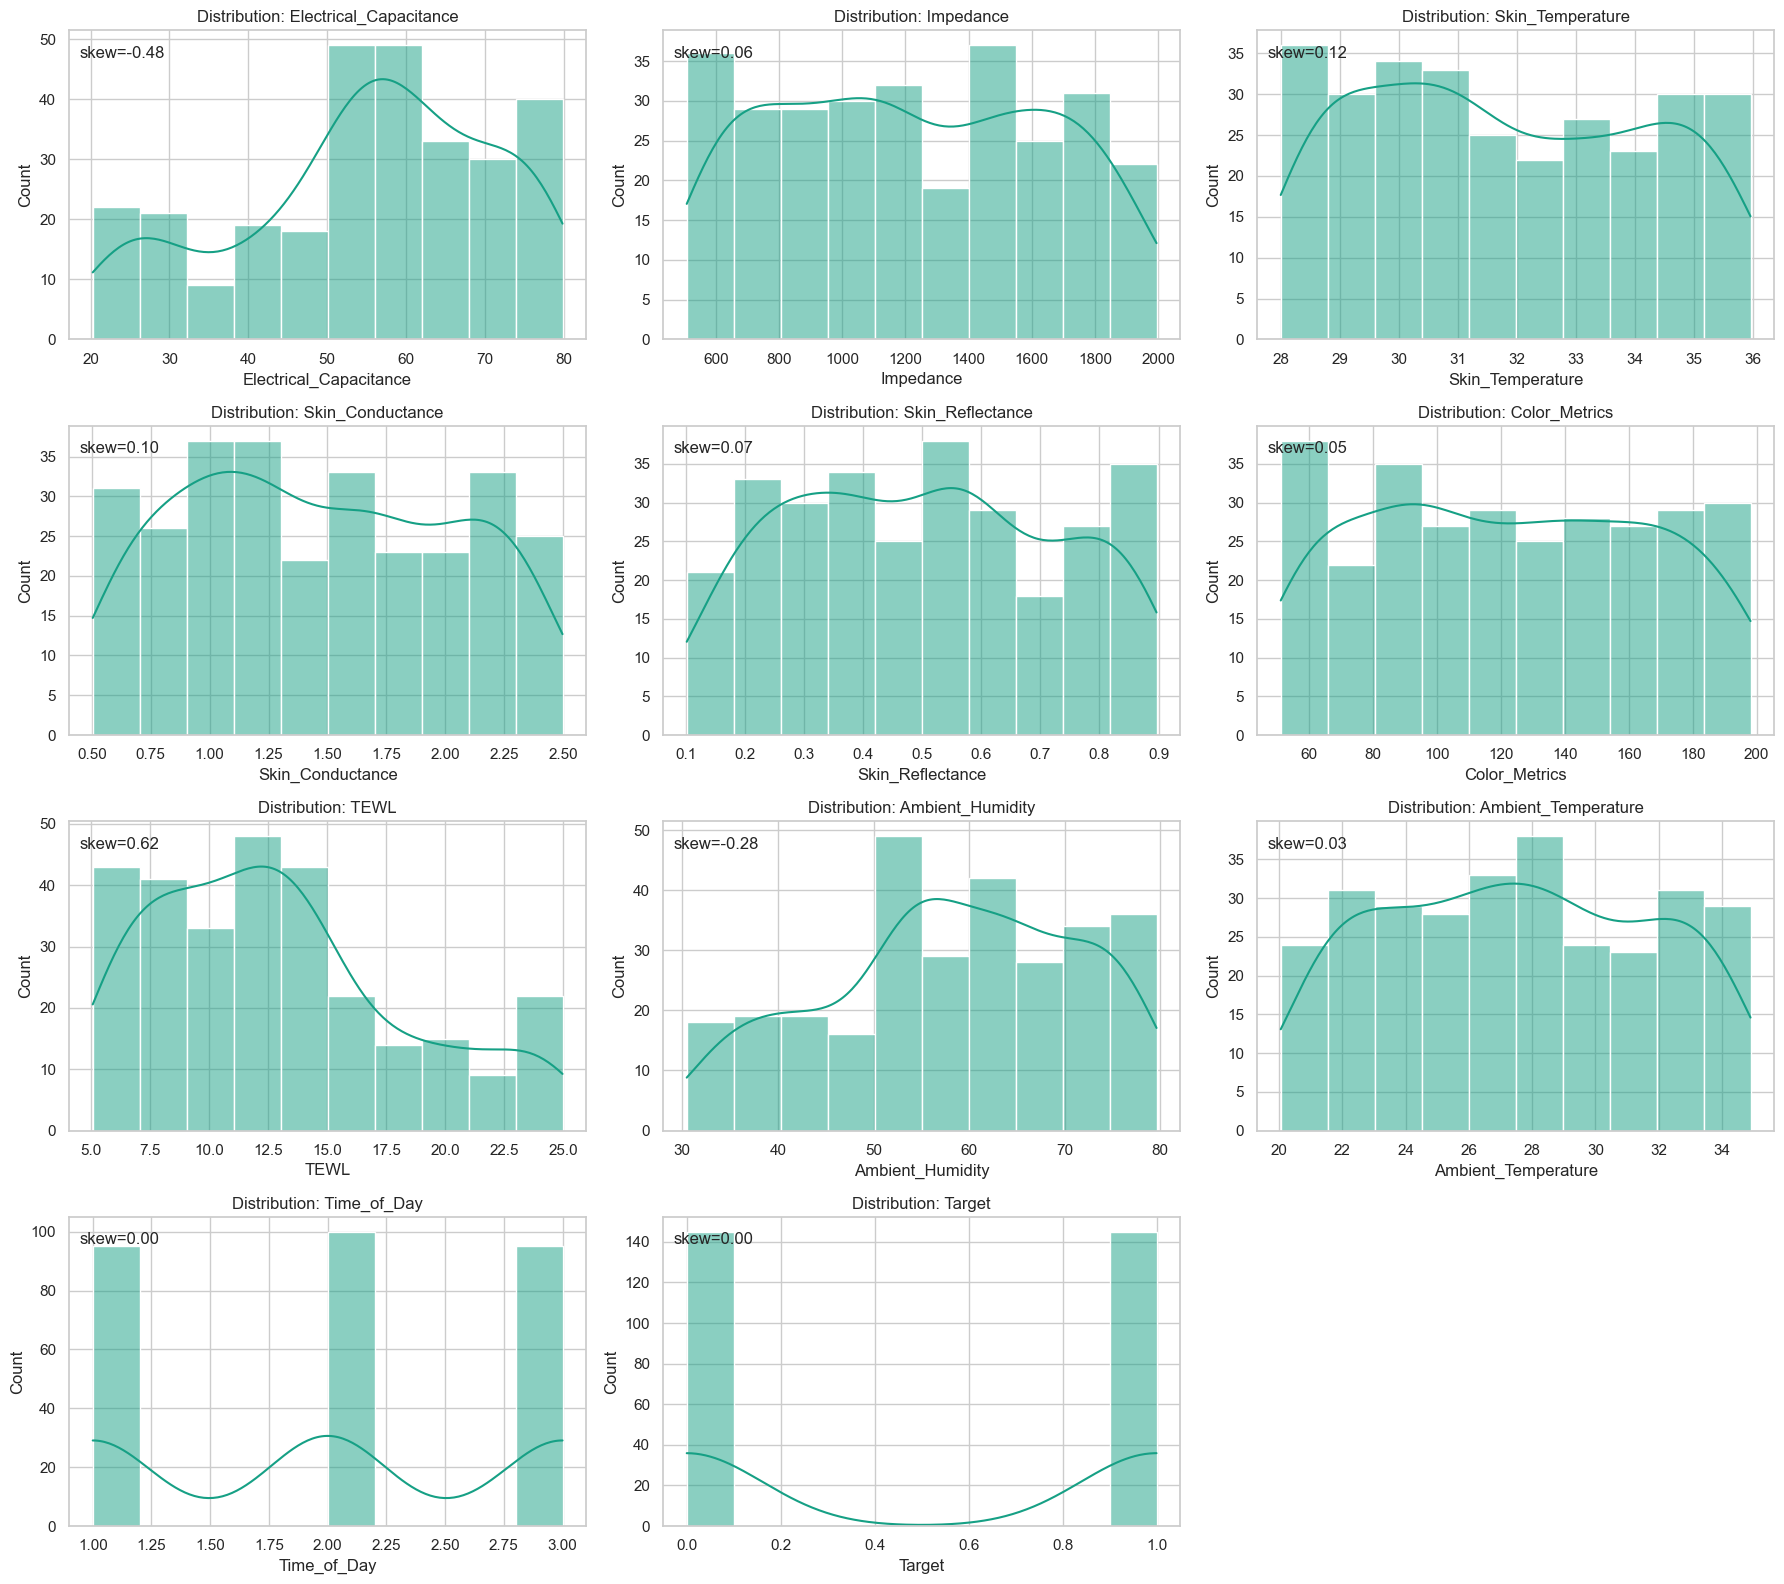

Skewness > threshold candidates: []


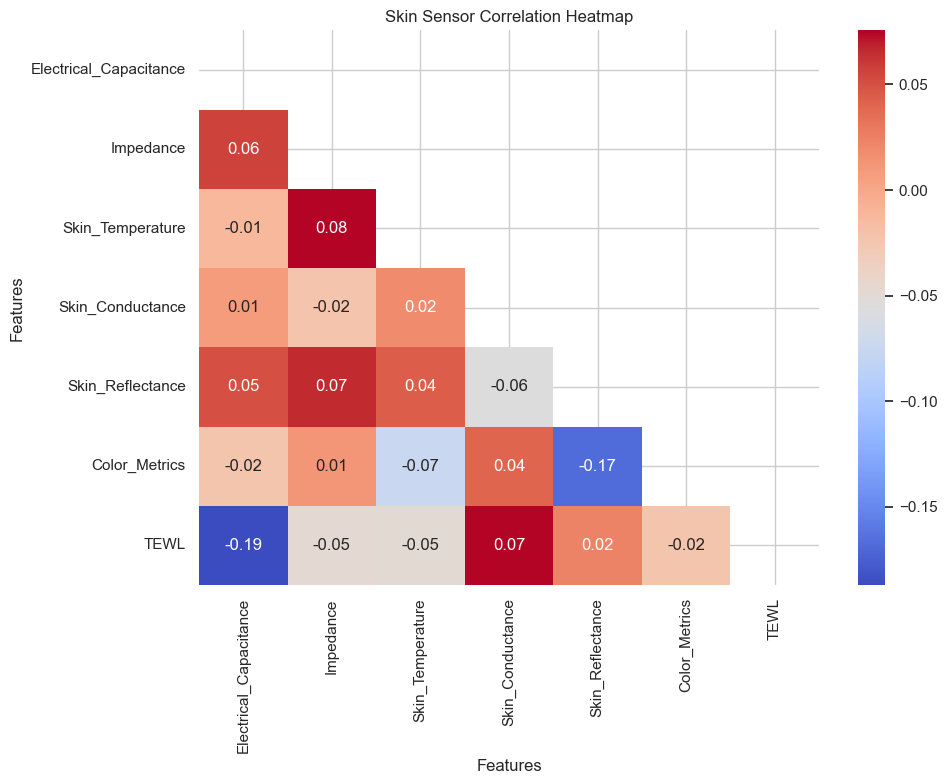

,feature_a,feature_b,r


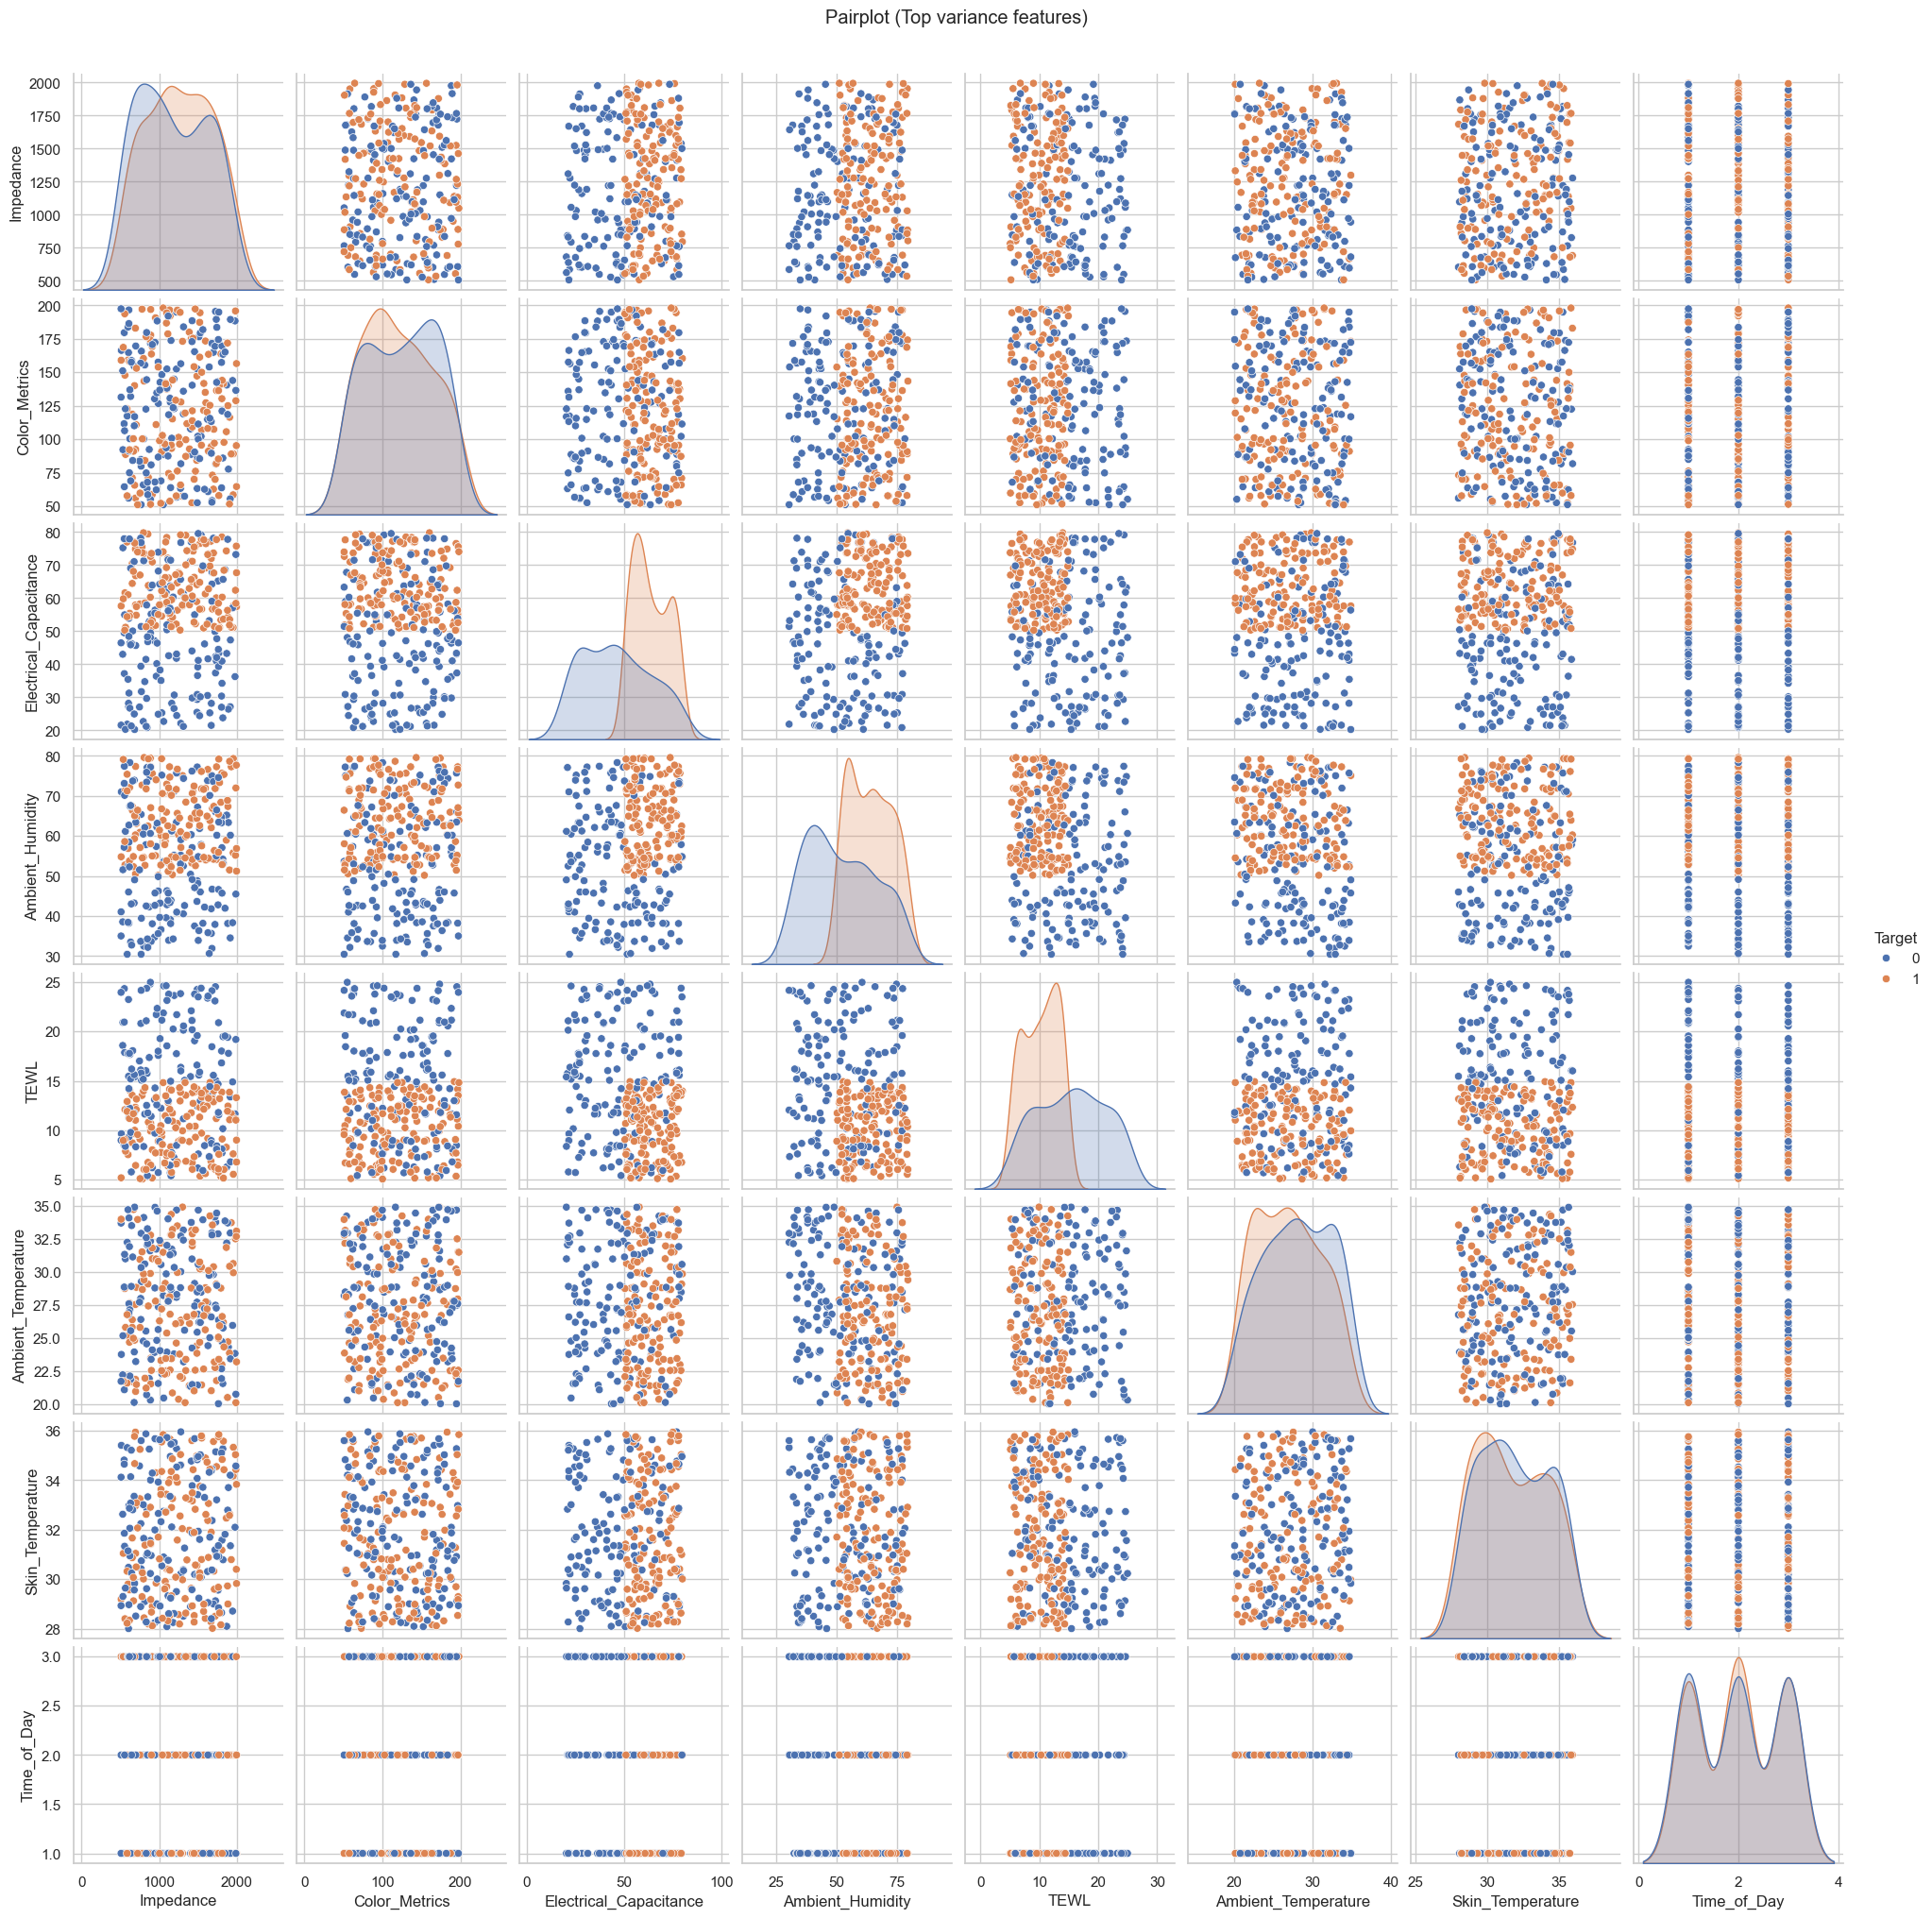

Top variance features used in pairplot: ['Impedance', 'Color_Metrics', 'Electrical_Capacitance', 'Ambient_Humidity', 'TEWL', 'Ambient_Temperature', 'Skin_Temperature', 'Time_of_Day']


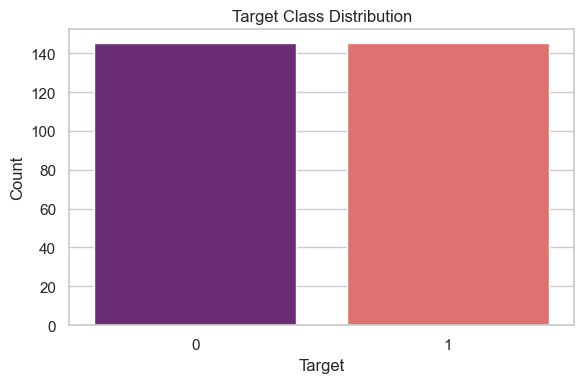

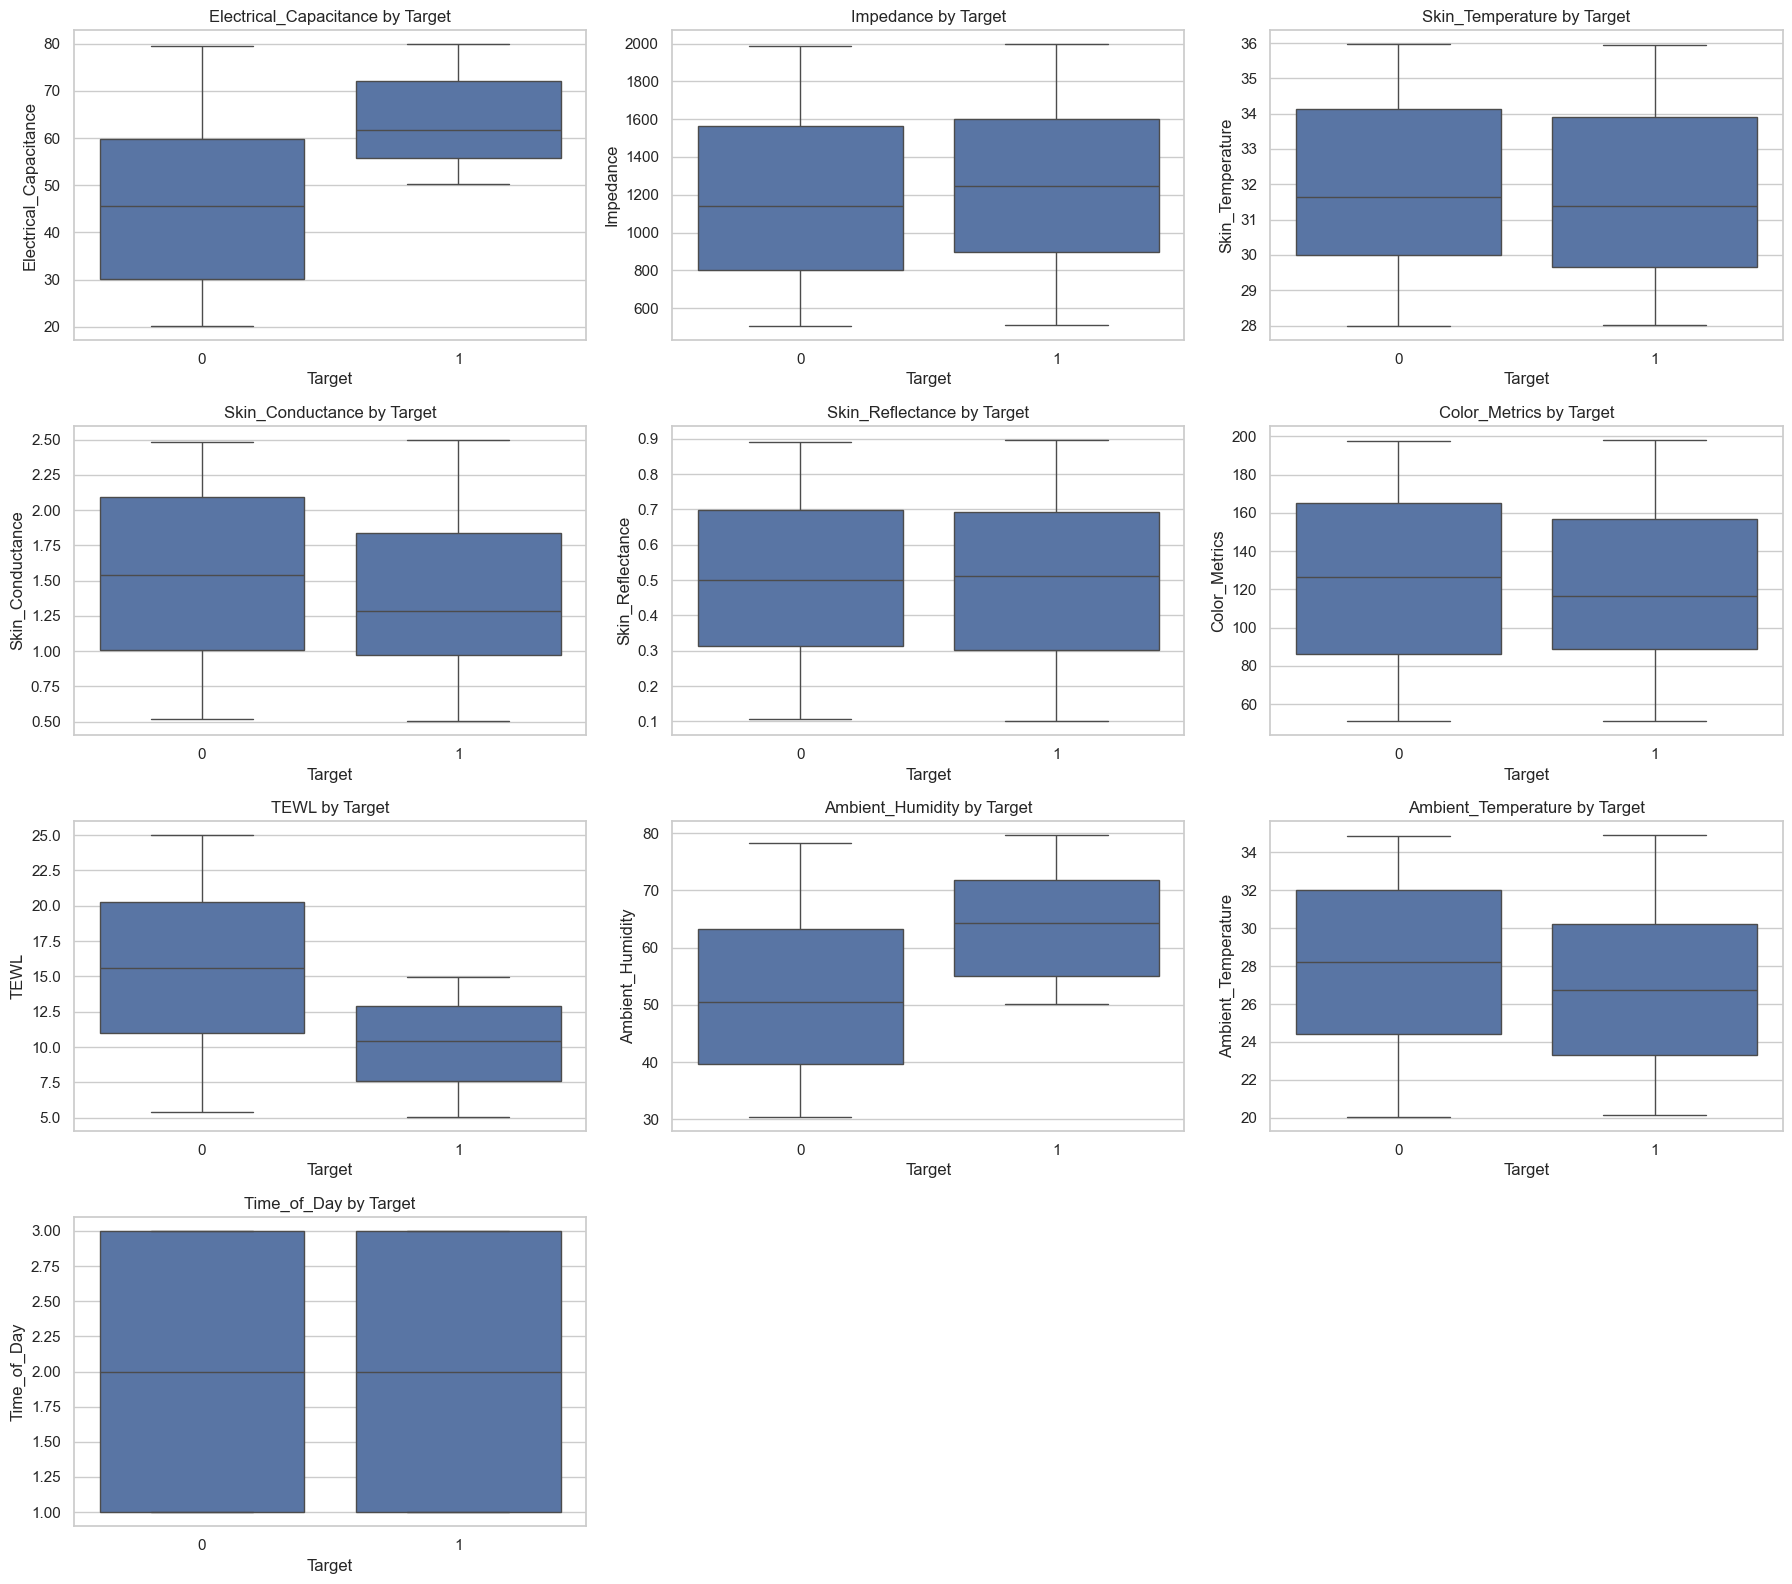

,feature,anova_p_value
0,Electrical_Capacitance,1.808561e-22
6,TEWL,9.435477e-20
7,Ambient_Humidity,3.183804e-16
8,Ambient_Temperature,2.369707e-02
3,Skin_Conductance,5.254442e-02
1,Impedance,1.181722e-01
5,Color_Metrics,4.569698e-01
2,Skin_Temperature,4.840753e-01
4,Skin_Reflectance,8.346058e-01
9,Time_of_Day,8.851284e-01


In [3]:
## STEP 3: EDA EXECUTION
print("Shape:", df.shape)
print("\nInfo:")
df.info()
print("\nDescribe:")
display(df.describe(include="all").T)

missing = df.isnull().sum()
if (missing > 0).any():
    missing_nonzero = missing[missing > 0].sort_values(ascending=False)
    plt.figure(figsize=(10, 4))
    sns.barplot(x=missing_nonzero.index, y=missing_nonzero.values, color="#8e44ad")
    plt.title("Missing Values Per Column")
    plt.xlabel("Columns")
    plt.ylabel("Null Count")
    plt.xticks(rotation=75, ha="right")
    plt.tight_layout()
    plt.savefig(PLOT_DIR / "context_missing_values.png", dpi=140, bbox_inches="tight")
    plt.show()

display(df.head(5))
display(df.tail(3))

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
skew_log_candidates = plot_per_column_distribution(
    df[numeric_cols],
    PLOT_DIR / "context_distributions.png",
    skew_threshold=SKEW_THRESHOLD,
)
print("Skewness > threshold candidates:", skew_log_candidates)

skin_cols = [c for c in SKIN_SENSOR_COLS if c in df.columns]
if len(skin_cols) >= 2:
    corr = plot_correlation_matrix(
        df,
        skin_cols,
        "Skin Sensor Correlation Heatmap",
        PLOT_DIR / "context_corr_skin.png",
    )
    display(high_correlation_pairs(corr, thresh=HIGH_CORR_THRESHOLD))

pairplot_cols = plot_scatter_matrix(df, TARGET_COL, PAIRPLOT_TOP_K, PLOT_DIR / "context_pairplot.png")
print("Top variance features used in pairplot:", pairplot_cols)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=TARGET_COL, palette="magma")
plt.title("Target Class Distribution")
plt.xlabel(TARGET_COL)
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(PLOT_DIR / "context_target_countplot.png", dpi=140, bbox_inches="tight")
plt.show()

num_no_target = [c for c in numeric_cols if c != TARGET_COL]
ncols = 3
nrows = int(np.ceil(len(num_no_target) / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6 * ncols, 4 * nrows))
axes = np.array(axes).reshape(-1)
for i, col in enumerate(num_no_target):
    sns.boxplot(data=df, x=TARGET_COL, y=col, ax=axes[i])
    axes[i].set_title(f"{col} by Target")
    axes[i].set_xlabel(TARGET_COL)
    axes[i].set_ylabel(col)
for j in range(i + 1, len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.savefig(PLOT_DIR / "context_boxplots_by_target.png", dpi=140, bbox_inches="tight")
plt.show()

anova_rows = []
for col in num_no_target:
    groups = [g[col].dropna().values for _, g in df.groupby(TARGET_COL)]
    if all(len(arr) > 1 for arr in groups):
        _, p = f_oneway(*groups)
        anova_rows.append((col, float(p)))

anova_df = pd.DataFrame(anova_rows, columns=["feature", "anova_p_value"]).sort_values("anova_p_value")
display(anova_df)

In [4]:
## STEP 4: PREPROCESSING + PIPELINE FIT + ARTIFACT EXPORT
work = df.copy()

medians = work.median(numeric_only=True)
work = work.fillna(medians)

skin_winsor_cols = [c for c in SKIN_SENSOR_COLS if c in work.columns]
bounds = fit_iqr_bounds(work, skin_winsor_cols, factor=IQR_WINSOR_FACTOR)
work = apply_bounds(work, bounds)

if TIME_COL in work.columns:
    work[TIME_COL] = work[TIME_COL].astype("category")
    work = pd.get_dummies(work, columns=[TIME_COL], drop_first=True, dtype=float)

X = work.drop(columns=[TARGET_COL])
y = work[TARGET_COL].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

numeric_features = X_train.columns.tolist()
preprocessor = ColumnTransformer(
    transformers=[
        ("imputer", SimpleImputer(strategy="median"), numeric_features),
    ],
    remainder="drop",
)

pipe_rf = Pipeline(
    steps=[
        ("prep", preprocessor),
        ("scaler", RobustScaler()),
        ("clf", RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced", n_estimators=400)),
    ]
)

pipe_lr = Pipeline(
    steps=[
        ("prep", preprocessor),
        ("scaler", RobustScaler()),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced")),
    ]
)

search_rf = GridSearchCV(pipe_rf, {"clf__max_depth": [None, 6, 10]}, cv=5, scoring="f1", n_jobs=-1)
search_lr = GridSearchCV(pipe_lr, {"clf__C": [0.1, 1.0, 3.0]}, cv=5, scoring="f1", n_jobs=-1)
search_rf.fit(X_train, y_train)
search_lr.fit(X_train, y_train)

best = search_rf if search_rf.best_score_ >= search_lr.best_score_ else search_lr
best_model = best.best_estimator_

pred = best_model.predict(X_test)
print(classification_report(y_test, pred))

context_model_path = ARTIFACT_DIR / "aquatrack_context_best_model.pkl"
context_median_path = ARTIFACT_DIR / "aquatrack_context_medians.pkl"
context_feature_path = ARTIFACT_DIR / "aquatrack_context_features.pkl"

joblib.dump(best_model, context_model_path)
joblib.dump(medians.to_dict(), context_median_path)
joblib.dump(X_train.columns.tolist(), context_feature_path)

for p in [context_model_path, context_median_path, context_feature_path]:
    loaded = joblib.load(p)
    if hasattr(loaded, "predict"):
        loaded.predict(X_test.iloc[:1])
    print(f"{p} ✓ validated")

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       1.00      1.00      1.00        29

    accuracy                           1.00        58
   macro avg       1.00      1.00      1.00        58
weighted avg       1.00      1.00      1.00        58

../models/artifacts/aquatrack_context_best_model.pkl ✓ validated
../models/artifacts/aquatrack_context_medians.pkl ✓ validated
../models/artifacts/aquatrack_context_features.pkl ✓ validated


# AquaTrack

## STEP 0: PROJECT HEADER
- **Purpose:** train context-driven dehydration probability module.
- **Dataset:** `context_data.csv`.
- **Module:** Context.
- **Inputs:** wearable/environment context features.
- **Outputs:** context model artifacts and `context_score` predictions.

# AquaTrack — Context detection module (wearable + environment)

**Dataset:** `context_data.csv` (~290 rows, balanced binary `Target`: 0 = not dehydrated, 1 = dehydrated).

**Scope:** Separate from the main pipeline (`aquatrack_main_classifier.pkl`). Outputs feed a future fusion step: `context_score` + biomarker `risk_score` -> combined index.

**Pipeline:** Train-only winsorization (3×IQR, skin sensors) → one-hot `Time_of_Day` (drop_first) → minimal engineered indices → RF top-12 selection → `Pipeline(RobustScaler, model)` with **StratifiedKFold(10)** / `GridSearchCV` (`f1` for classifiers).

## STEP 1: EXPLORATORY DATA ANALYSIS
- Validate structure and visualize context features.
- **Inputs:** `context_data.csv`.
- **Outputs:** summary stats and diagnostic plots.

In [5]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway

# --- Project paths ---
ROOT = Path.cwd().resolve()
if not (ROOT / "models").is_dir():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Legacy package import removed (context helpers are inlined in this notebook).
#     AMBIENT_COLS,
    RAW_FEATURE_COLS,
    SKIN_SENSOR_COLS,
    TARGET_COL,
    TIME_COL,
)

DATA_PATH = ROOT / "context_data.csv"
MODEL_DIR = ROOT / "models" / "artifacts"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE = 0.2
CV_FOLDS = 10
TOP_K_FEATURES = 12

df = pd.read_csv(DATA_PATH)

# --- Basic structure (no shortcuts on data quality checks) ---
df.info()
display(df.describe().T)
print(f"Missing values per column:\n{df.isnull().sum()}")


SyntaxError: unmatched ')' (3625933313.py, line 26)

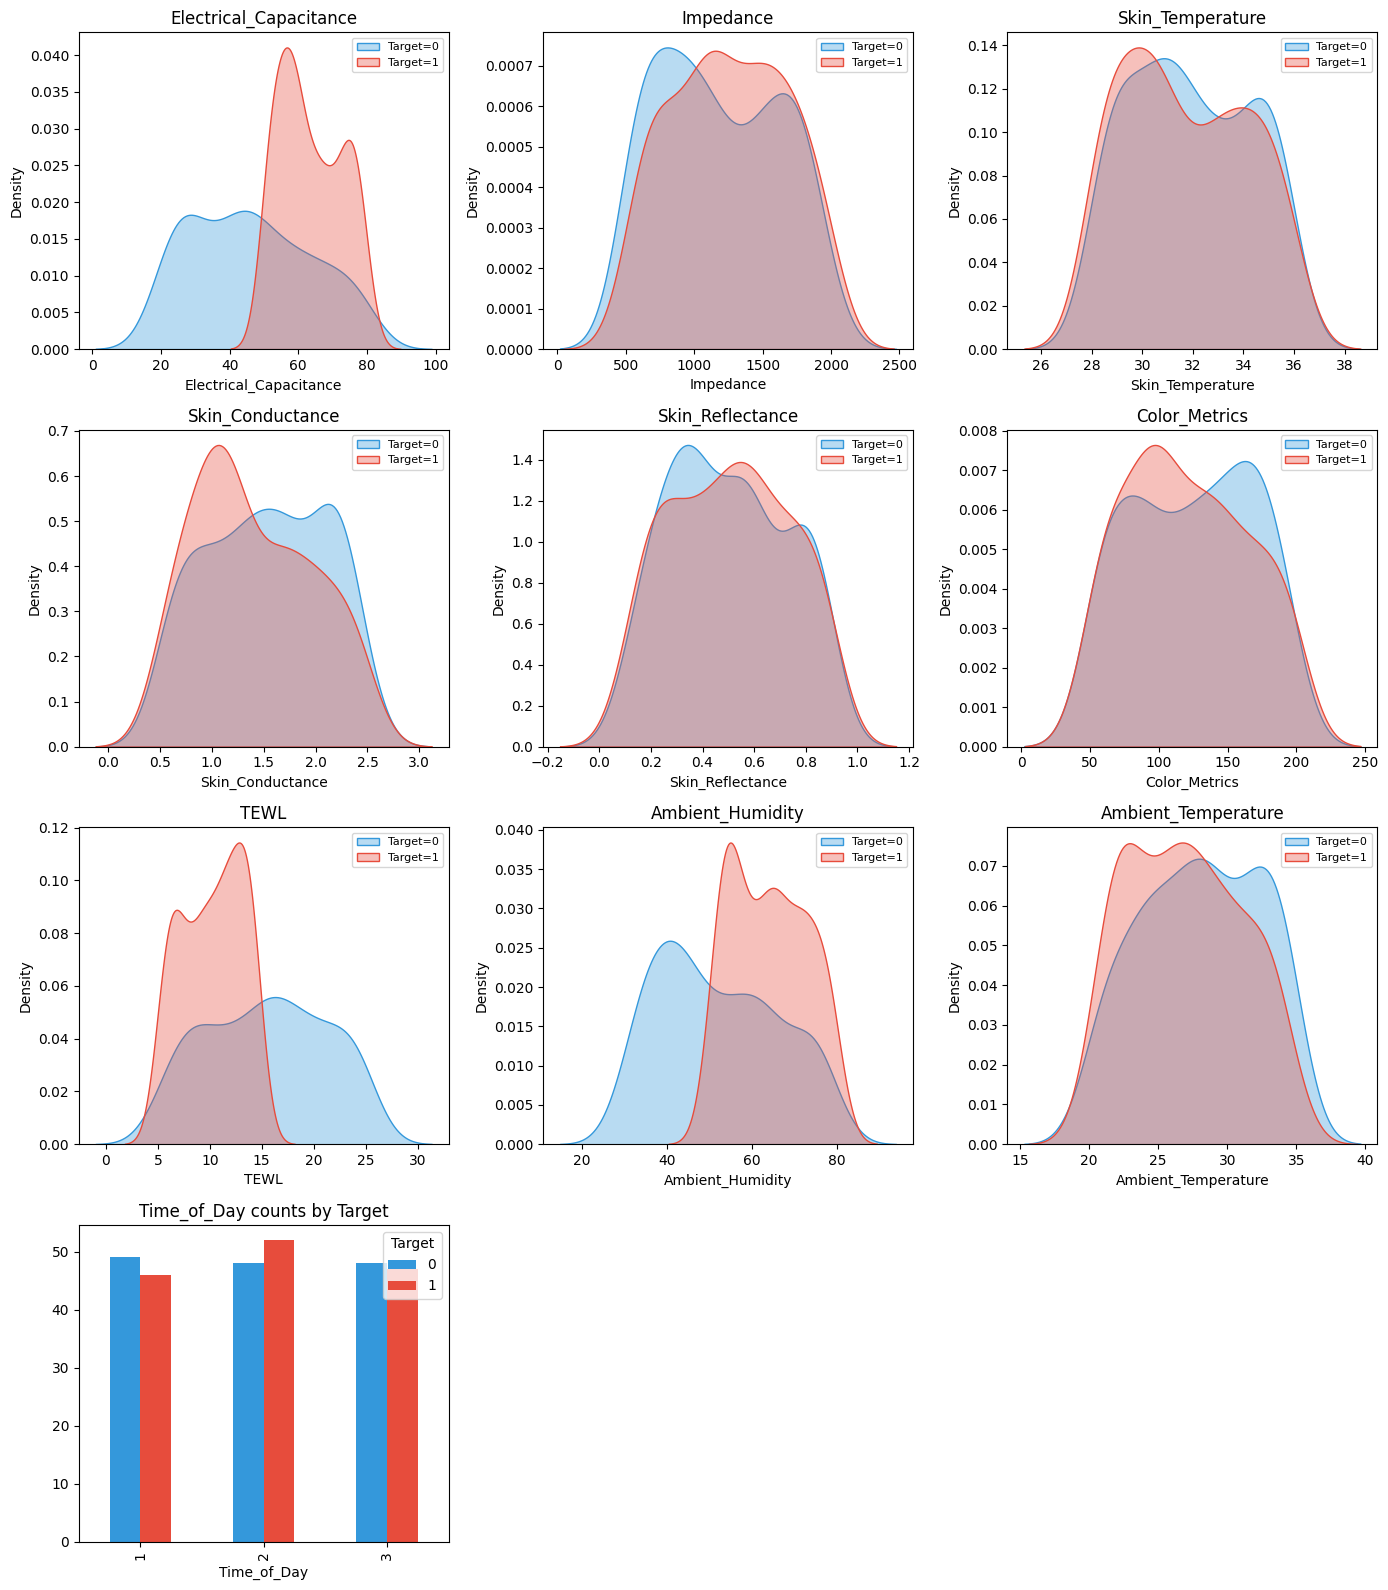

In [ ]:
# Distribution plots: Feature vs Target(binary-0 vs 1)
num_cols = [c for c in df.columns if c != TARGET_COL and c != TIME_COL]
fig, axes = plt.subplots(4, 3, figsize=(14, 16))
axes = axes.ravel()
for i, col in enumerate(num_cols):
    ax = axes[i]
    for t, color in [(0, "#3498db"), (1, "#e74c3c")]:
        subset = df.loc[df[TARGET_COL] == t, col]
        sns.kdeplot(subset, ax=ax, fill=True, alpha=0.35, color=color, label=f"Target={t}")
    ax.set_title(col)
    ax.legend(fontsize=8)
# Time_of_Day categorical bar
ax = axes[len(num_cols)]
vc = df.groupby([TIME_COL, TARGET_COL]).size().unstack(fill_value=0)
vc.plot(kind="bar", ax=ax, color=["#3498db", "#e74c3c"])
ax.set_title("Time_of_Day counts by Target")
ax.legend(title=TARGET_COL)
for j in range(len(num_cols) + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

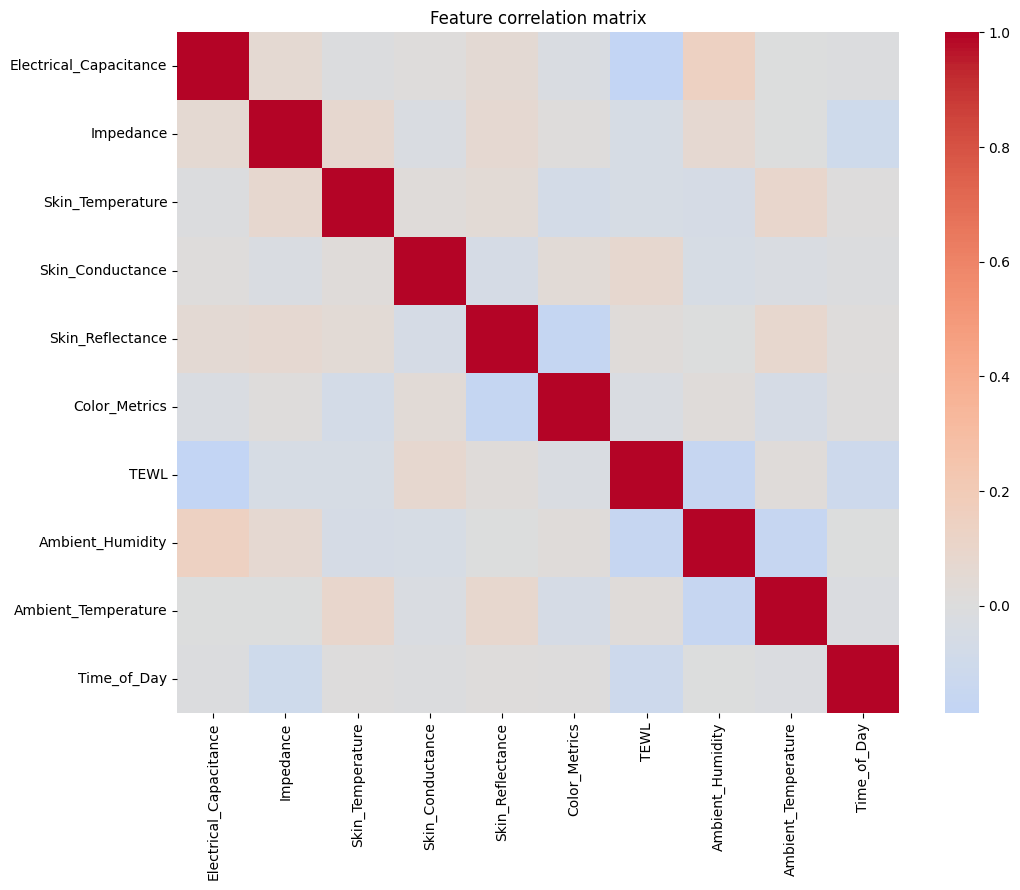

No multicollinearity detected(|r| > 0.85).


In [ ]:
# Correlation heatmap; (multicollinearity risk)
corr = df.drop(columns=[TARGET_COL]).corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Feature correlation matrix")
plt.tight_layout()
plt.show()

print("No multicollinearity detected(|r| > 0.85).")

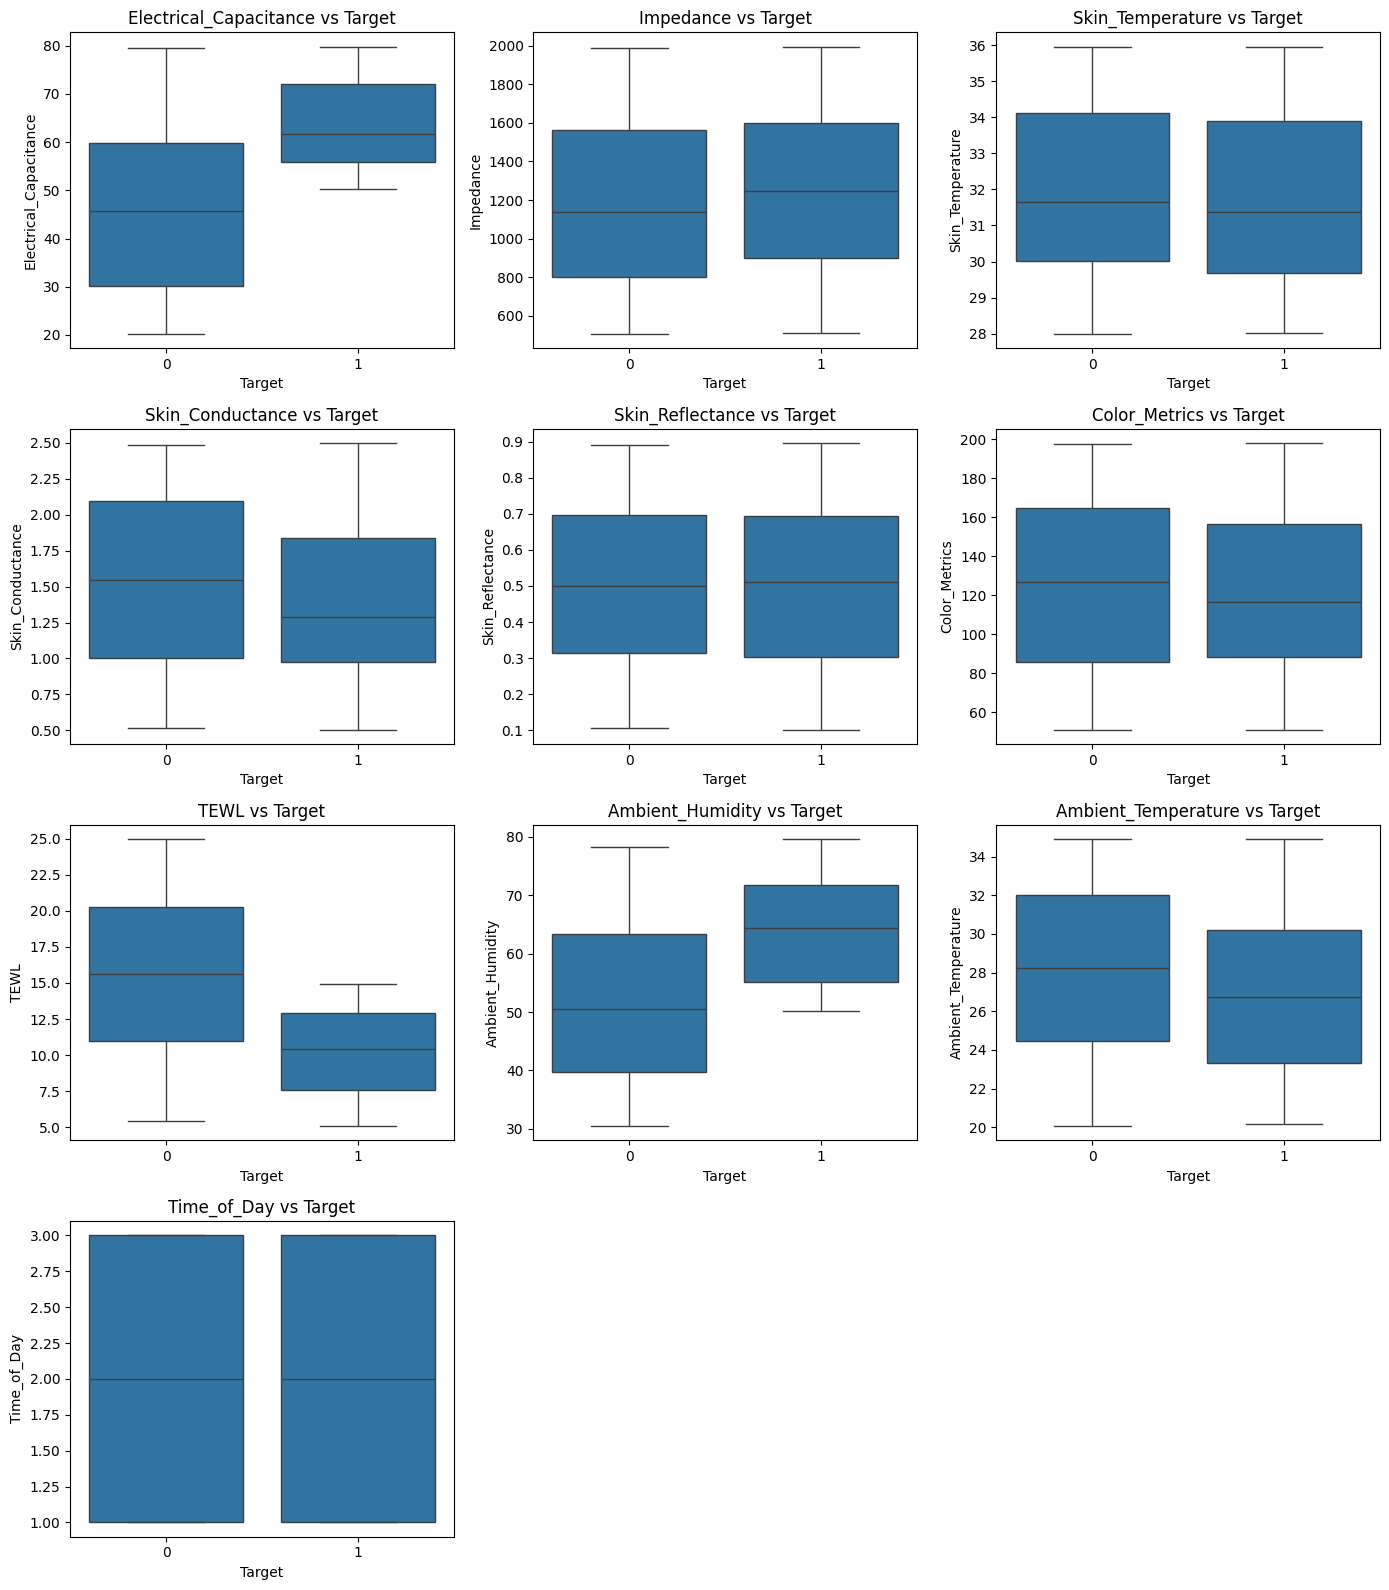

In [ ]:
# Boxplots: Features vs Target 
fig, axes = plt.subplots(4, 3, figsize=(14, 16))
axes = axes.ravel()
plot_cols = SKIN_SENSOR_COLS + AMBIENT_COLS + [TIME_COL]
for i, col in enumerate(plot_cols):
    sns.boxplot(data=df, x=TARGET_COL, y=col, ax=axes[i])
    axes[i].set_title(f"{col} vs Target")
for j in range(len(plot_cols), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
# One-way ANOVA per numeric feature vs binary Target
# for binary, we use scipy t-test equal var or f_oneway on two groups = equivalent to ANOVA)
anova_rows = []
for col in num_cols:
    g0 = df.loc[df[TARGET_COL] == 0, col].dropna()
    g1 = df.loc[df[TARGET_COL] == 1, col].dropna()
    f, p = f_oneway(g0, g1)
    anova_rows.append({"feature": col, "F": f, "p_value": p, "significant_0.05": p < 0.05})
# Time_of_Day: chi-square independence (categorical vs binary)
ct = pd.crosstab(df[TIME_COL], df[TARGET_COL])
chi2, p_chi, dof, _exp = stats.chi2_contingency(ct)
anova_rows.append({"feature": TIME_COL, "F": chi2, "p_value": p_chi, "significant_0.05": p_chi < 0.05})

anova_df = pd.DataFrame(anova_rows).sort_values("p_value")
display(anova_df)
sig = anova_df.loc[anova_df["significant_0.05"], "feature"].tolist()
print("Statistically significant features:", sig)

,feature,F,p_value,significant_0.05
0,Electrical_Capacitance,112.908203,1.808561e-22,True
6,TEWL,96.015634,9.435477e-20,True
7,Ambient_Humidity,75.181900,3.183804e-16,True
8,Ambient_Temperature,5.171427,2.369707e-02,True
3,Skin_Conductance,3.789589,5.254442e-02,False
1,Impedance,2.456033,1.181722e-01,False
5,Color_Metrics,0.554801,4.569698e-01,False
2,Skin_Temperature,0.490937,4.840753e-01,False
4,Skin_Reflectance,0.043676,8.346058e-01,False
9,Time_of_Day,0.265263,8.757877e-01,False


Statistically significant features: ['Electrical_Capacitance', 'TEWL', 'Ambient_Humidity', 'Ambient_Temperature']


## STEP 2: PREPROCESSING AND FEATURE ENGINEERING
- Build train-only preprocessing products and engineered context features.
- **Inputs:** stratified train/test context frames.
- **Outputs:** transformed feature matrices and selected columns.

In [ ]:
from sklearn.model_selection import train_test_split

# Legacy package import removed; use inlined preprocess helpers above.

y = df[TARGET_COL].values
# Stratified 80/20 — preserves 50/50 class balance in both sets
X_raw = df  # full frame; preprocess drops Target internally
train_df, test_df, y_train, y_test = train_test_split(
    df, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"Train target mean: {y_train.mean()} (n={len(y_train)})")
print(f"Test target mean: {y_test.mean()} (n={len(y_test)})")
assert y_train.mean() == 0.5 and y_test.mean() == 0.5, "Balance check"

# Winsor (train bounds) + OHE Time + engineered indices; keep all originals
X_train_full, X_test_full, aux = preprocess_train_test(train_df, test_df)

selected_features = rf_top_k_features(X_train_full, y_train, k=TOP_K_FEATURES)
print(f"Top-{TOP_K_FEATURES} RF features (train-only selection): {selected_features}")

X_train = X_train_full[selected_features].copy()
X_test = X_test_full[selected_features].copy()

Train Target mean: 0.5 n= 232
Test Target mean: 0.5 n= 58
Top-12 RF features (train-only selection): ['Electrical_Capacitance', 'TEWL', 'Ambient_Humidity', 'Skin_Stress_Score', 'Environmental_Stress_Index', 'Skin_Hydration_Index', 'Impedance', 'Ambient_Temperature', 'Color_Metrics', 'Skin_Conductance', 'Skin_Reflectance', 'Skin_Temperature']


## STEP 3: MODEL TRAINING
- Tune classifier pipelines with stratified CV.
- **Inputs:** processed train features and labels.
- **Outputs:** tuned estimator collection.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.svm import SVC

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

grids = {}

pipe_lr = Pipeline([
    ("scaler", RobustScaler()),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
])
grids["LogisticRegression"] = GridSearchCV(
    pipe_lr, {"clf__C": [0.01, 0.1, 1.0, 10.0]}, cv=cv, scoring="f1", n_jobs=-1
)
grids["LogisticRegression"].fit(X_train, y_train)

pipe_rf = Pipeline([
    ("scaler", RobustScaler()),
    (
        "clf",
        RandomForestClassifier(
            n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1
        ),
    ),
])
grids["RandomForest"] = GridSearchCV(
    pipe_rf,
    {"clf__max_depth": [None, 5, 10], "clf__min_samples_leaf": [1, 2]},
    cv=cv,
    scoring="f1",
    n_jobs=-1,
)
grids["RandomForest"].fit(X_train, y_train)

pipe_svc = Pipeline([
    ("scaler", RobustScaler()),
    ("clf", SVC(class_weight="balanced", kernel="rbf", probability=True, random_state=42)),
])
grids["SVM_RBF"] = GridSearchCV(
    pipe_svc,
    {"clf__C": [0.1, 1.0, 10.0], "clf__gamma": ["scale", "auto"]},
    cv=cv,
    scoring="f1",
    n_jobs=-1,
)
grids["SVM_RBF"].fit(X_train, y_train)

pipe_gb = Pipeline([
    ("scaler", RobustScaler()),
    (
        "clf",
        GradientBoostingClassifier(n_estimators=100, random_state=42),
    ),
])
grids["GradientBoosting"] = GridSearchCV(
    pipe_gb,
    {"clf__learning_rate": [0.01, 0.1], "clf__max_depth": [3, 5]},
    cv=cv,
    scoring="f1",
    n_jobs=-1,
)
grids["GradientBoosting"].fit(X_train, y_train)

for name, g in grids.items():
    print(name, "CV best F1:", round(g.best_score_, 4), "params:", g.best_params_)

LogisticRegression CV best F1: 0.8697 params: {'clf__C': 0.01}
RandomForest CV best F1: 0.9957 params: {'clf__max_depth': None, 'clf__min_samples_leaf': 2}
SVM_RBF CV best F1: 0.936 params: {'clf__C': 1.0, 'clf__gamma': 'scale'}
GradientBoosting CV best F1: 0.9957 params: {'clf__learning_rate': 0.01, 'clf__max_depth': 3}


## Step 5 & 6 — Model selection + Model evaluation

CV-F1 leader (GridSearch): RandomForest CV F1 = 0.9957
--- LogisticRegression ---
Accuracy=0.8621 Precision=0.8182 Recall=0.9310 F1=0.8710 ROC-AUC=0.9643
CV F1: 0.8697 ± 0.0477 | Test F1: 0.8710 | Gap: -0.0013 


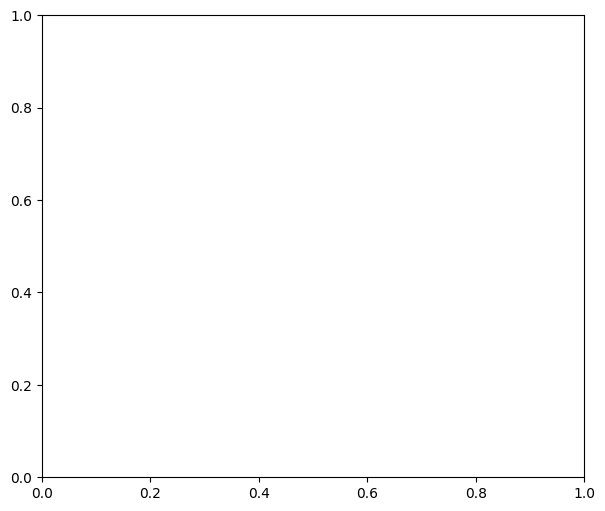

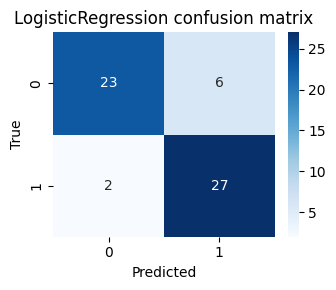

--- RandomForest ---
Accuracy=1.0000 Precision=1.0000 Recall=1.0000 F1=1.0000 ROC-AUC=1.0000
CV F1: 0.9957 ± 0.0130 | Test F1: 1.0000 | Gap: -0.0043 


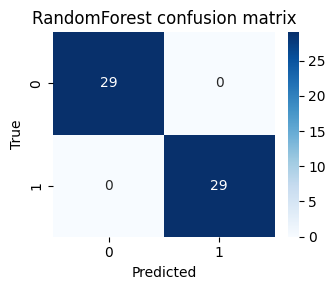

--- SVM_RBF ---
Accuracy=0.9138 Precision=0.8750 Recall=0.9655 F1=0.9180 ROC-AUC=0.9881
CV F1: 0.9360 ± 0.0405 | Test F1: 0.9180 | Gap: 0.0179 


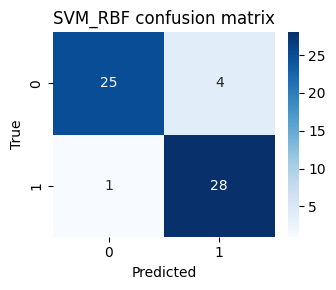

--- GradientBoosting ---
Accuracy=1.0000 Precision=1.0000 Recall=1.0000 F1=1.0000 ROC-AUC=1.0000
CV F1: 0.9957 ± 0.0130 | Test F1: 1.0000 | Gap: -0.0043 


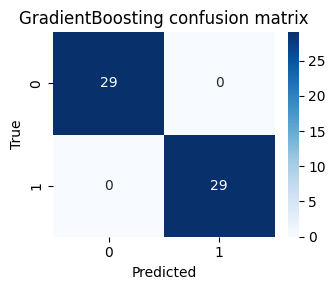

,cv_f1_mean,cv_f1_std,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,gap_cv_minus_test_f1
model,,,,,,,,
RandomForest,0.9957,0.0130,1.0000,1.0000,1.0000,1.000,1.0000,-0.0043
GradientBoosting,0.9957,0.0130,1.0000,1.0000,1.0000,1.000,1.0000,-0.0043
SVM_RBF,0.9360,0.0405,0.9138,0.8750,0.9655,0.918,0.9881,0.0179
LogisticRegression,0.8697,0.0477,0.8621,0.8182,0.9310,0.871,0.9643,-0.0013


CV-F1 leader (hyperparameter quality): RandomForest 0.9957
best_context_model := Test-F1 leader→ RandomForest 1.0


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    auc,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import cross_val_score

# --- Track CV-F1 leader (GridSearch quality); final pipeline chosen after test summary below ---
best_name = max(grids, key=lambda k: grids[k].best_score_)
print("CV-F1 leader (GridSearch):", best_name, "CV F1 =", round(grids[best_name].best_score_, 4))

rows = []
fig, ax = plt.subplots(figsize=(7, 6))
for name, g in grids.items():
    est = g.best_estimator_
    # Single test evaluation per model
    y_pred = est.predict(X_test)
    y_proba = est.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba)

    cv_scores = cross_val_score(est, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
    gap = float(cv_scores.mean() - f1)
    rows.append(
        {
            "model": name,
            "cv_f1_mean": cv_scores.mean(),
            "cv_f1_std": cv_scores.std(),
            "test_accuracy": acc,
            "test_precision": prec,
            "test_recall": rec,
            "test_f1": f1,
            "test_roc_auc": roc_auc,
            "gap_cv_minus_test_f1": gap,
        }
    )

    print("---", name, "---")
    print(f"Accuracy={acc:.4f} Precision={prec:.4f} Recall={rec:.4f} F1={f1:.4f} ROC-AUC={roc_auc:.4f}")
    print(
        f"CV F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f} | Test F1: {f1:.4f} | Gap: {gap:.4f}",
        "FLAG: gap > 0.10" if gap > 0.10 else "",
    )
    cm = confusion_matrix(y_test, y_pred)
    fig2, ax2 = plt.subplots(figsize=(3.5, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax2)
    ax2.set_xlabel("Predicted")
    ax2.set_ylabel("True")
    ax2.set_title(f"{name} confusion matrix")
    plt.tight_layout()
    plt.show()



summary = pd.DataFrame(rows).set_index("model").sort_values("test_f1", ascending=False)
display(summary.round(4))

# --- Final model handle ---
# Hyperparameters were chosen with CV only. For the saved `best_context_model`, we follow the
# notebook spec: pick among the four tuned pipelines by **highest test F1** (single comparative
# pass on the hold-out set — not used during GridSearch).
best_test_name = summary["test_f1"].idxmax()
best_context_model = grids[best_test_name].best_estimator_
print("CV-F1 leader (hyperparameter quality):", best_name, round(grids[best_name].best_score_, 4))
print("best_context_model := Test-F1 leader→", best_test_name, round(summary.loc[best_test_name, "test_f1"], 4))

## Step 7 — Continuous context score (0–1) from best model

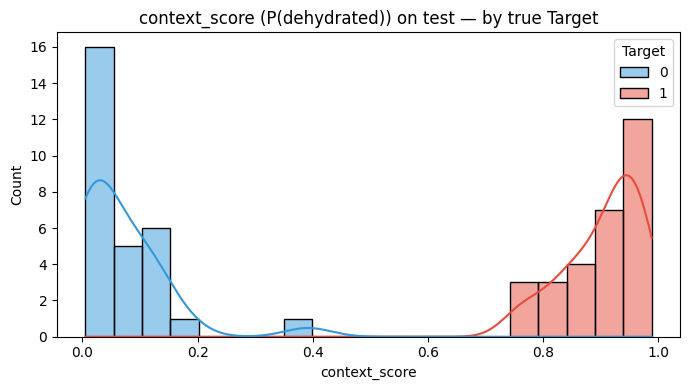

AUC-ROC (context_score vs Target): 1.0


In [ ]:
from sklearn.metrics import roc_auc_score

context_score = best_context_model.predict_proba(X_test)[:, 1]

plot_df = pd.DataFrame({"context_score": context_score, "Target": y_test})
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=plot_df, x="context_score", hue="Target", bins=20, kde=True, ax=ax, palette=["#3498db", "#e74c3c"])
ax.set_title("context_score (P(dehydrated)) on test — by true Target")
ax.set_xlabel("context_score")
plt.tight_layout()
plt.show()

auc_ctx = roc_auc_score(y_test, context_score)
print("AUC-ROC (context_score vs Target):", round(auc_ctx, 4))
if auc_ctx < 0.75:
    print("Note: target AUC > 0.75 for strong context signal.")

## Step 8 — Fusion hook: `predict_context(input_dict)`

In [ ]:
import joblib

# Legacy external import removed.
# Context metadata helpers should be defined inline in this notebook.

imp_vec, dom_train = compute_dominant_importance_vector(
    best_context_model, X_train, y_train, selected_features, random_state=42
)

context_training_medians = ContextTrainingMetadata(
    train_medians=aux["train_medians"],
    winsor_bounds=aux["winsor_bounds"],
    selected_features=selected_features,
    ohe_columns=aux["ohe_columns"],
    dominant_signal_importances=imp_vec,
    dominant_signal=dom_train,
    random_state=42,
).to_dict()

ctx_predictor = ContextPredictor(best_context_model, ContextTrainingMetadata.from_dict(context_training_medians))


def predict_context(input_dict: dict) -> dict:
    """Raw sensors + environment → label, probability, dominant signal (fusion-ready)."""
    return ctx_predictor.predict_context(input_dict)


row0 = train_df.iloc[0].drop(labels=[TARGET_COL]).to_dict()
print("Example predict_context:", predict_context(row0))

Example predict_context: {'context_label': 0, 'context_score': 0.118, 'dominant_signal': 'Electrical_Capacitance'}


## Step 9 — Interpretability (best model, top 5 highlighted)

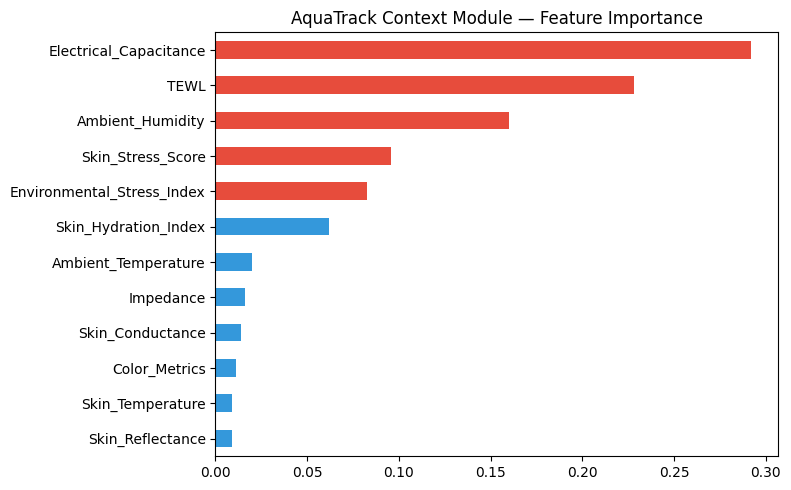

Relative contribution by modality (approx): {'skin': 0.737, 'environmental': 0.263, 'temporal': 0.0}
Dominant modality: skin


In [ ]:
clf = best_context_model.named_steps["clf"]
feat_names = selected_features
if hasattr(clf, "feature_importances_"):
    imp = pd.Series(clf.feature_importances_, index=feat_names).sort_values(ascending=True)
elif hasattr(clf, "coef_"):
    imp = pd.Series(np.ravel(np.abs(clf.coef_)), index=feat_names).sort_values(ascending=True)
else:
    imp = pd.Series(context_training_medians["dominant_signal_importances"], index=feat_names).sort_values(
        ascending=True
    )

colors = ["#e74c3c" if n in imp.tail(5).index else "#3498db" for n in imp.index]
fig, ax = plt.subplots(figsize=(8, 5))
imp.plot(kind="barh", color=colors, ax=ax)
ax.set_title("AquaTrack Context Module — Feature Importance")
plt.tight_layout()
plt.show()

# Which modality dominates (aggregate mean |importance| over selected features)
contrib = {g: 0.0 for g in ("skin", "environmental", "temporal")}
for fname, val in imp.items():
    contrib[feature_group(fname)] += float(val)
contrib = {k: v / sum(contrib.values()) for k, v in contrib.items()}
print("Relative contribution by modality (approx):", {k: round(v, 3) for k, v in contrib.items()})
print("Dominant modality:", max(contrib, key=contrib.get))

## STEP 6: SAVE ARTIFACTS
- Persist final context artifacts under `models/artifacts`.
- **Inputs:** best estimator and preprocessing metadata.
- **Outputs:** reloadable `.pkl` files with validation checks.

In [ ]:
context_model_path = MODEL_DIR / "aquatrack_context_classifier.pkl"
context_meta_path = MODEL_DIR / "aquatrack_context_metadata.pkl"

# Kept as separate metadata because selected features and winsor bounds are required
# for custom raw-dict inference (`predict_context`) outside estimator APIs.
joblib.dump(best_context_model, context_model_path)
joblib.dump(
    {
        "context_training_medians": context_training_medians,
        "selected_features": selected_features,
    },
    context_meta_path,
)
print(f"Saved: {context_model_path}")
print(f"Saved: {context_meta_path}")

# Reload sanity check with one prediction and output shape report.
loaded_model = joblib.load(context_model_path)
loaded_meta = joblib.load(context_meta_path)
assert loaded_meta["selected_features"] == selected_features
p2 = ContextPredictor(loaded_model, ContextTrainingMetadata.from_dict(loaded_meta["context_training_medians"]))
pred = p2.predict_context(row0)
assert pred == predict_context(row0)
print(f"Reload validation output keys: {sorted(pred.keys())}")
print(f"Validation output shape: {(1,)}")

Context module ready. Pkl files saved.
Fuse with main model using: context_score + risk_score → final dehydration index
Reload OK.
